### Churn Analysis

In [3]:
# import libraries
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()
db_url = os.getenv("DATABASE_URL")

if db_url is None:
    print("Cant find the database URL.")
else:
    engine = create_engine(db_url)
    print("Successfully connected to the database!")



df = pd.read_sql(
    "SELECT * FROM churn_cleaned",
    engine
)

Successfully connected to the database!


In [4]:
# see top 5 rows of the dataframe
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [5]:
# Create churn flag
df["churn_flag"] = df["churn"].map({
    "Yes": 1,
    "No": 0
})

#### Function to calculate segment impact

In [7]:
def segment_risk_analysis(data, segment_column):

    result = (
        data.groupby(segment_column)
        .agg(
            total_customers=("customer_id", "count"),
            churned_customers=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean")
        )
        .reset_index()
    )


    # Active customers
    active = (
        data[data["churn"] == "No"]
        .groupby(segment_column)
        .agg(
            active_customers=("customer_id", "count"),
            active_revenue=("monthly_charges", "sum")
        )
        .reset_index()
    )


    result = result.merge(
        active,
        on=segment_column,
        how="left"
    )


    # Convert churn rate
    result["churn_rate"] = (
        result["churn_rate"] * 100
    ).round(2)


    # Future exposure
    result["future_revenue_exposure"] = (
        result["active_revenue"]
        *
        result["churn_rate"]
        /
        100
    )


    return result

#### Contract wise segment analysis

In [8]:
contract_analysis = segment_risk_analysis(
    df,
    "contract"
)

contract_analysis

,contract,total_customers,churned_customers,churn_rate,active_customers,active_revenue,future_revenue_exposure
0,Month-to-month,3875,1655,42.71,2220,136447.05,58276.535055
1,One year,1473,166,11.27,1307,81698.15,9207.381505
2,Two year,1695,48,2.83,1647,98840.55,2797.187565


#### Tenure wise segment analysis

In [10]:
df["tenure_segment"] = pd.cut(
    df["tenure"],
    bins=[-1,12,36,100],
    labels=[
        "New Customer",
        "Existing Customer",
        "Loyal Customer"
    ]
)

In [11]:
tenure_analysis = segment_risk_analysis(
    df,
      "tenure_segment"
)

tenure_analysis

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\2966186430.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(segment_column)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\2966186430.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(segment_column)


,tenure_segment,total_customers,churned_customers,churn_rate,active_customers,active_revenue,future_revenue_exposure
0,New Customer,2186,1037,47.44,1149,53675.50,25463.65720
1,Existing Customer,1856,474,25.54,1382,79139.05,20212.11337
2,Loyal Customer,3001,358,11.93,2643,184171.20,21971.62416


#### Payment method wise segment analysis

In [12]:
payment_analysis = segment_risk_analysis(
    df,
    "payment_method"
)

payment_analysis

,payment_method,total_customers,churned_customers,churn_rate,active_customers,active_revenue,future_revenue_exposure
0,Bank transfer (automatic),1544,258,16.71,1286,83653.55,13978.508205
1,Credit card (automatic),1522,232,15.24,1290,83285.25,12692.672100
2,Electronic check,2365,1071,45.29,1294,96056.25,43503.875625
3,Mailed check,1612,308,19.11,1304,53990.70,10317.622770


Among the analyzed customer segmentation dimensions, contract type represented the largest churn-related future revenue exposure impact. Month-to-month customers accounted for the majority of future revenue exposure ($58276K), making them the primary target segment for further churn analysis.

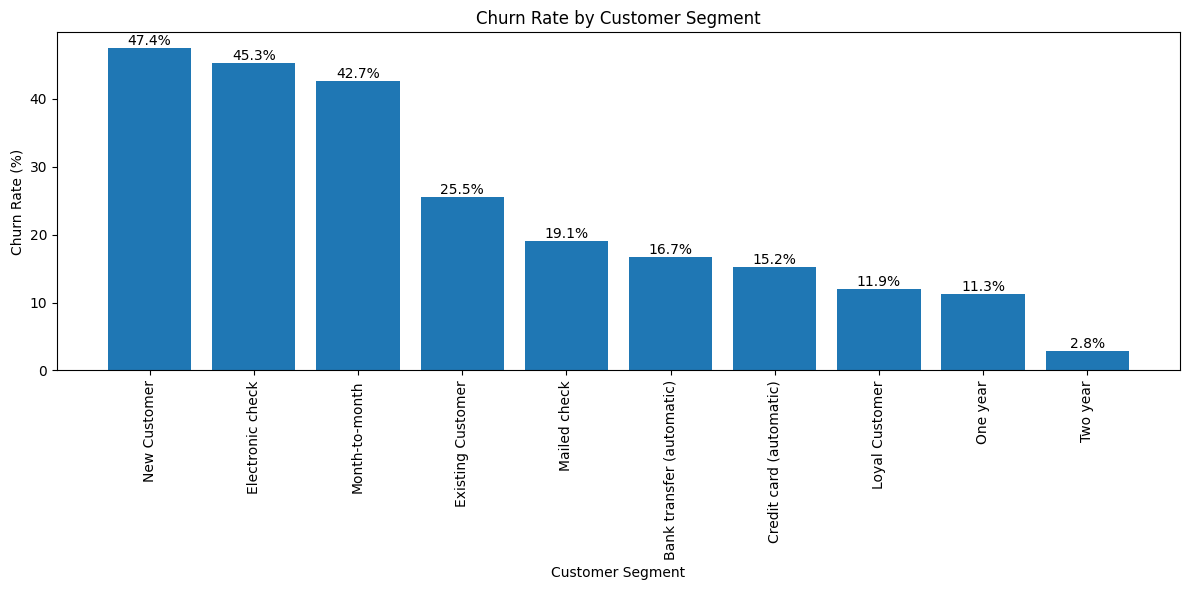

In [25]:
# Create labels

contract_plot = contract_analysis.copy()
contract_plot["segment"] = contract_plot["contract"].astype(str)

tenure_plot = tenure_analysis.copy()
tenure_plot["segment"] = tenure_plot["tenure_segment"].astype(str)

payment_plot = payment_analysis.copy()
payment_plot["segment"] = payment_plot["payment_method"].astype(str)


# Combine only churn rate

combined_analysis = pd.concat(
    [
        contract_plot[["segment", "churn_rate"]],
        tenure_plot[["segment", "churn_rate"]],
        payment_plot[["segment", "churn_rate"]]
    ],
    ignore_index=True
)


# Sort highest churn first

combined_analysis = combined_analysis.sort_values(
    "churn_rate",
    ascending=False
)


# Plot

plt.figure(figsize=(12,6))

plt.bar(
    combined_analysis["segment"],
    combined_analysis["churn_rate"]
)

plt.title(
    "Churn Rate by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Churn Rate (%)"
)

plt.xticks(
    rotation=90
)


# Add values

for i, value in enumerate(combined_analysis["churn_rate"]):
    plt.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

#### Month-to-Month Segment Analysis

In [19]:
month_to_month = df[
    df["contract"] == "Month-to-month"
]

#### Drivers Analysis

#### Find churn rate for future revenue exposure Analysis

In [20]:
month_churned = month_to_month[
    month_to_month["churn"] == "Yes"
]

drivers = [
    "tech_support",
    "online_security",
    "online_backup",
    "device_protection",
    "payment_method",
    "internet_service"
]

driver_analysis = []

for d in drivers:
    
    # Revenue lost from churned customers
    revenue = (
        month_churned
        .groupby(d)["monthly_charges"]
        .sum()
        .reset_index()
    )
    
    revenue = revenue.rename(
        columns={
            d: "category",
            "monthly_charges": "revenue_lost"
        }
    )
    
    
    # Historical churn rate among all month-to-month customers
    churn_rate = (
        month_to_month
        .groupby(d)["churn_flag"]
        .mean()
        .mul(100)
        .round(2)
        .reset_index()
    )
    
    churn_rate = churn_rate.rename(
        columns={
            d: "category",
            "churn_flag": "historical_churn_rate"
        }
    )
    
    
    # Merge revenue loss and churn rate
    result = revenue.merge(
        churn_rate,
        on="category",
        how="left"
    )
    
    result["driver"] = d
    
    driver_analysis.append(result)


# Combine all drivers
driver_revenue_table = pd.concat(
    driver_analysis,
    ignore_index=True
)


# Final table
driver_revenue_table = driver_revenue_table[
    [
        "driver",
        "category",
        "historical_churn_rate",
        "revenue_lost"
    ]
]


driver_revenue_table.sort_values(
    "revenue_lost",
    ascending=False
)

,driver,category,historical_churn_rate,revenue_lost
3,online_security,No,51.05,102397.55
0,tech_support,No,50.37,102382.25
17,internet_service,Fiber optic,54.61,100482.00
6,online_backup,No,50.31,84890.80
9,device_protection,No,47.58,82715.80
14,payment_method,Electronic check,53.73,77315.60
11,device_protection,Yes,43.57,36133.45
8,online_backup,Yes,38.10,33958.45
16,internet_service,DSL,32.22,18367.25
2,tech_support,Yes,30.70,16467.00


#### Future Revenue Exposure Analysis

In [21]:
# 2. Select priority segment
# Month-to-month customers
month_to_month = df[
    df["contract"] == "Month-to-month"
]


# 3. Historical churn rates (from past behaviour)
# This is used as the risk probability
historical_rates = {}

drivers = [
    "online_security",
    "tech_support",
    "internet_service",
    "online_backup",
    "device_protection",
    "payment_method"
]


for driver in drivers:
    
    rate = (
        month_to_month
        .groupby(driver)["churn_flag"]
        .mean()
        .mul(100)
        .round(2)
    )
    
    for category, value in rate.items():
        historical_rates[(driver, category)] = value



# 4. Current active Month-to-month customers
# These are future risk candidates
active_month = month_to_month[
    month_to_month["churn"] == "No"
]


# 5. Calculate future revenue exposure
future_risk = []


for driver in drivers:
    
    categories = active_month[driver].unique()
    
    for category in categories:
        
        group = active_month[
            active_month[driver] == category
        ]
        
        revenue = group["monthly_charges"].sum()
        customers = len(group)
        
        churn_rate = historical_rates.get(
            (driver, category),
            0
        )
        
        future_risk.append({
            "driver": driver,
            "category": category,
            "historical_churn_rate": churn_rate,
            "customers_at_risk": customers,
            "revenue_exposed": round(revenue,2)
        })


# 6. Create final table
future_risk_table = pd.DataFrame(future_risk)


# 7. Sort by revenue exposure
future_risk_table = future_risk_table.sort_values(
    "revenue_exposed",
    ascending=False
)


future_risk_table

,driver,category,historical_churn_rate,customers_at_risk,revenue_exposed
3,tech_support,No,50.37,1330,93152.00
0,online_security,No,51.05,1288,91001.90
7,internet_service,Fiber optic,54.61,966,84699.10
12,device_protection,No,47.58,1255,84079.45
10,online_backup,No,50.31,1137,77053.75
15,payment_method,Electronic check,53.73,856,61414.95
9,online_backup,Yes,38.10,658,50696.55
13,device_protection,Yes,43.57,540,43670.85
6,internet_service,DSL,32.22,829,43051.20
1,online_security,Yes,29.58,507,36748.40


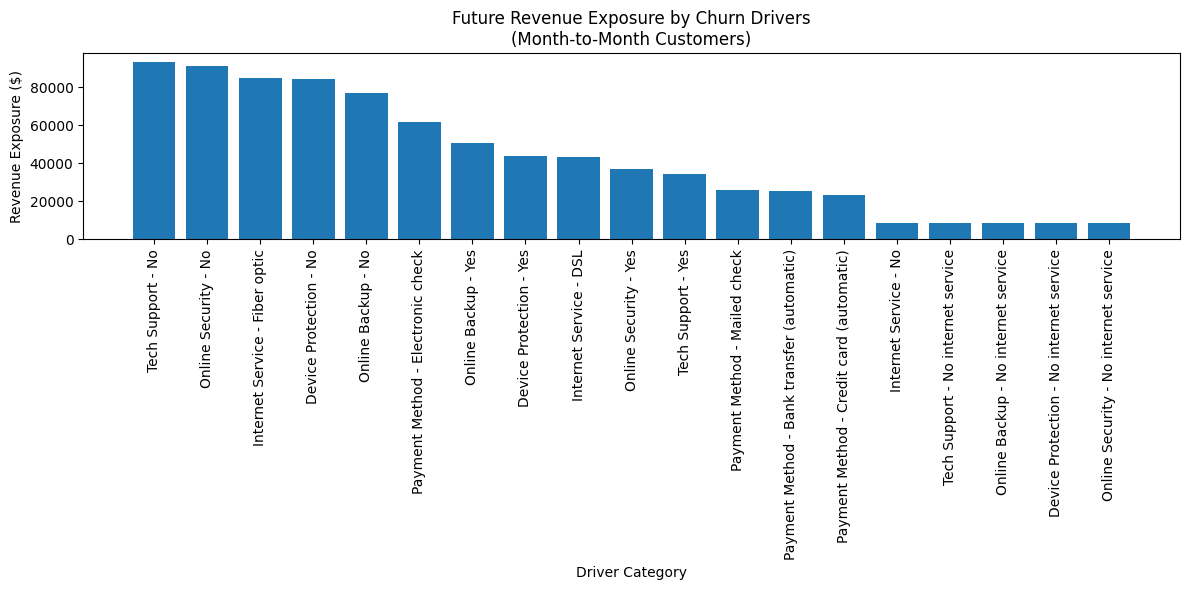

In [24]:
import matplotlib.pyplot as plt

# Create label
future_risk_table["driver_category"] = (
    future_risk_table["driver"].str.replace("_", " ").str.title()
    + " - "
    + future_risk_table["category"].astype(str)
)

# Sort by revenue exposure
revenue_plot = future_risk_table.sort_values(
    "revenue_exposed",
    ascending=False
)


plt.figure(figsize=(12,6))

plt.bar(
    revenue_plot["driver_category"],
    revenue_plot["revenue_exposed"]
)

plt.title(
    "Future Revenue Exposure by Churn Drivers\n(Month-to-Month Customers)"
)

plt.xlabel(
    "Driver Category"
)

plt.ylabel(
    "Revenue Exposure ($)"
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

#### Conclusion

Analyzed 7,043 customer records using SQL and Python, identifying a 26.5% churn rate and estimating potential future revenue exposure among active customers based on historical churn behaviour.

Segmented active customers by contract type, tenure, and payment behaviour to identify future revenue risk segments, revealing Month-to-month customers as the highest-priority group with a 42.71% churn rate, 2,220 active customers, and $58K+ projected revenue exposure.

Examined risk drivers within the Month-to-month segment, identifying customers without Tech Support ($93K+ projected revenue exposure, 1,330 customers), without Online Security ($91K+ projected revenue exposure, 1,288 customers), and Fiber Optic Internet users ($84K+ projected revenue exposure, 966 customers) as the highest-priority retention groups.

Prioritized retention opportunities by ranking risk factors based on projected revenue exposure, highlighting Month-to-month customers with service gaps as key targets for reducing potential customer attrition.

In [16]:
contract_analysis.to_sql(
    "contract_analysis",
    engine,
    if_exists="replace",
    index=False
)


driver_revenue_table.to_sql(
    "driver_analysis",
    engine,
    if_exists="replace",
    index=False
)


future_risk_table.to_sql(
    "future_revenue_exposure",
    engine,
    if_exists="replace",
    index=False
)


print("Tables saved to database")

Tables saved to database
